1. Load Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from collections import Counter
import ast

2. Load the Datasets

In [ ]:

# Load behaviors.tsv

behaviors = pd.read_csv(
    "../raw/behaviors.tsv",
    sep="\t",
    header=None,
    names=["ImpressionID", "UserID", "Time", "History", "Impressions"]
)


# Load news.tsv

news = pd.read_csv(
    "../raw/news.tsv",
    sep="\t",
    header=None,
    names=["NewsID", "Category", "SubCategory", "Title", "Abstract",
           "URL", "TitleEntities", "AbstractEntities"]
)


In [4]:
behaviors

,ImpressionID,UserID,Time,History,Impressions,ImpressionList,Clicks,TotalShown
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,"[[N55689, 1], [N35729, 0]]",1,2
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,"[[N20678, 0], [N39317, 0], [N58114, 0], [N2049...",1,11
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,"[[N50014, 0], [N23877, 0], [N35389, 0], [N4971...",1,36
3,4,U34670,2019-11-11 05:28:05,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,"[[N35729, 0], [N33632, 0], [N49685, 1], [N2758...",1,4
4,5,U8125,2019-11-12 16:11:21,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,"[[N39985, 0], [N36050, 0], [N16096, 0], [N8400...",1,69
...,...,...,...,...,...,...,...,...
156960,156961,U21593,2019-11-14 22:24:05,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,"[[N2235, 0], [N22975, 0], [N64037, 0], [N47652...",1,31
156961,156962,U10123,2019-11-13 06:57:04,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,"[[N3841, 0], [N61571, 0], [N58813, 0], [N28213...",1,89
156962,156963,U75630,2019-11-14 10:58:13,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,"[[N55913, 0], [N62318, 0], [N53515, 0], [N1096...",1,43
156963,156964,U44625,2019-11-13 14:57:02,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,"[[N6219, 0], [N3663, 0], [N31147, 0], [N58363,...",5,119


In [5]:
news

,NewsID,Category,SubCategory,Title,Abstract,URL,TitleEntities,AbstractEntities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."
...,...,...,...,...,...,...,...,...
51277,N16909,weather,weathertopstories,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,https://assets.msn.com/labs/mind/BBWzQJK.html,"[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid...","[{""Label"": ""Woolsey Fire"", ""Type"": ""N"", ""Wikid..."
51278,N47585,lifestyle,lifestylefamily,Family says 13-year-old Broadway star died fro...,NaN,https://assets.msn.com/labs/mind/BBWzQYV.html,"[{""Label"": ""Broadway theatre"", ""Type"": ""F"", ""W...",[]
51279,N7482,sports,more_sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",https://assets.msn.com/labs/mind/BBWzQnK.html,[],[]
51280,N34418,sports,soccer_epl,How the Sounders won MLS Cup,"Mark, Jeremiah and Casey were so excited they ...",https://assets.msn.com/labs/mind/BBWzQuK.html,"[{""Label"": ""MLS Cup"", ""Type"": ""U"", ""WikidataId...",[]


3. Preprocess behaviors.tsv

In [3]:
# Convert time to datetime
behaviors['Time'] = pd.to_datetime(behaviors['Time'], format="%m/%d/%Y %I:%M:%S %p")

# Parse impressions into structured data
def parse_impressions(imp_str):
    return [x.split('-') for x in imp_str.split()]

# Expand impressions
behaviors['ImpressionList'] = behaviors['Impressions'].apply(parse_impressions)

# Count clicks and impressions
def count_clicks(impression_list):
    clicked = sum([int(click) for _, click in impression_list])
    total = len(impression_list)
    return pd.Series({'Clicks': clicked, 'TotalShown': total})

behaviors[['Clicks', 'TotalShown']] = behaviors['ImpressionList'].apply(count_clicks)

 PART 1: EDA for behaviors.tsv
1. Basic Structure
Dataset shape (rows x columns)

Check for missing values

Data types of each column

In [9]:
print(behaviors.shape)
print(behaviors.dtypes)
print(behaviors.isnull().sum())

(156965, 9)
ImpressionID               int64
UserID                    object
Time              datetime64[ns]
History                   object
Impressions               object
ImpressionList            object
Clicks                     int64
TotalShown                 int64
CTR                      float64
dtype: object
ImpressionID         0
UserID               0
Time                 0
History           3238
Impressions          0
ImpressionList       0
Clicks               0
TotalShown           0
CTR                  0
dtype: int64


2. User Behavior
Number of unique users

Distribution of number of impressions per user

Distribution of click history lengths (number of previously clicked articles)

Unique users: 50000


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


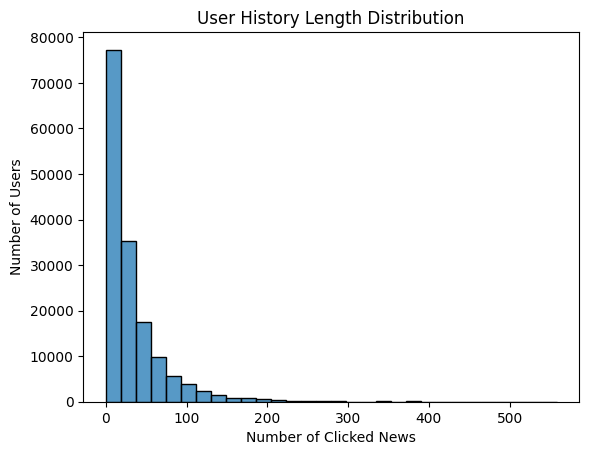

In [10]:
print("Unique users:", behaviors['UserID'].nunique())

# Impression count per user
user_impression_count = behaviors['UserID'].value_counts()

# History length
behaviors['HistoryLength'] = behaviors['History'].apply(lambda x: 0 if pd.isna(x) else len(x.split()))

# Plot
sns.histplot(behaviors['HistoryLength'], bins=30)
plt.title("User History Length Distribution")
plt.xlabel("Number of Clicked News")
plt.ylabel("Number of Users")
plt.show()

3. Time-Based Analysis
Number of impressions over time (daily/hourly)

Click trends over time

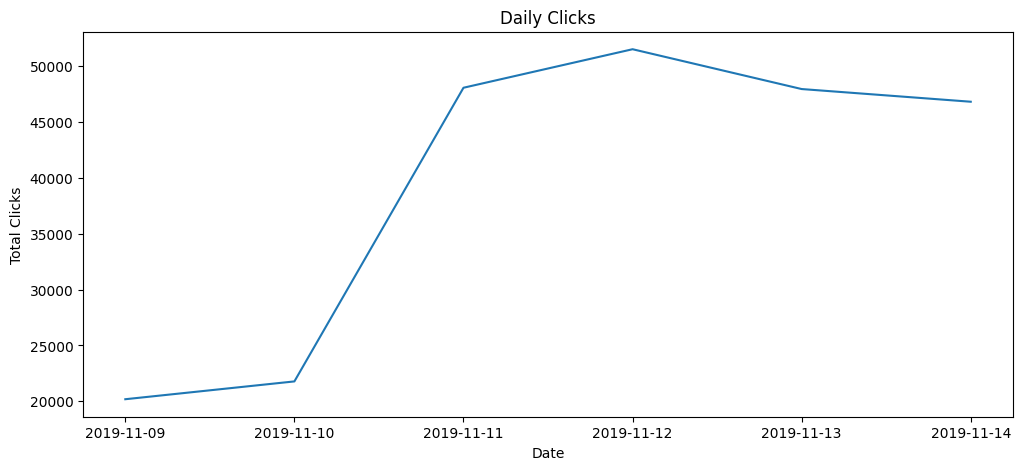

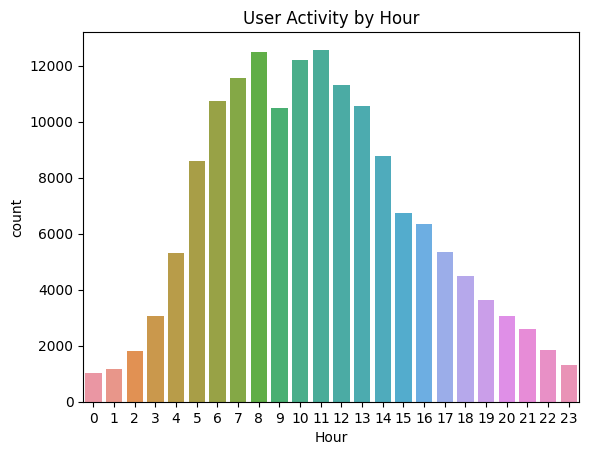

In [11]:
# Daily impressions
daily_clicks = behaviors.groupby(behaviors['Time'].dt.date)['Clicks'].sum()

daily_clicks.plot(figsize=(12, 5), title="Daily Clicks")
plt.xlabel("Date")
plt.ylabel("Total Clicks")
plt.show()

# Hourly activity
behaviors['Hour'] = behaviors['Time'].dt.hour
sns.countplot(data=behaviors, x='Hour')
plt.title("User Activity by Hour")
plt.show()

4. Click-Through Rate (CTR)
Calculate CTR per impression

Distribution of CTR

Average CTR

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


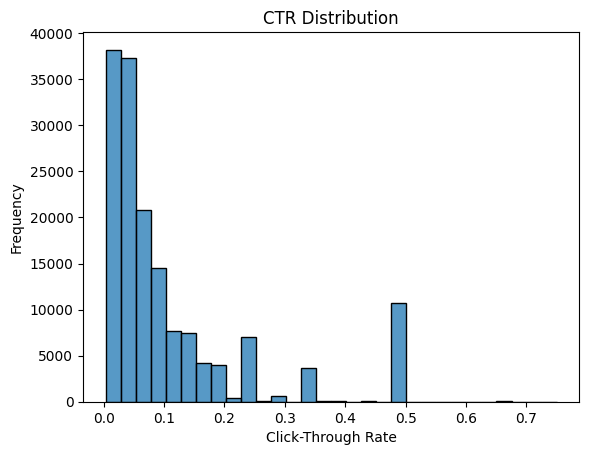

Average CTR: 0.10854419797471161


In [13]:
behaviors['CTR'] = behaviors['Clicks'] / behaviors['TotalShown']

# Plot CTR distribution
sns.histplot(behaviors['CTR'], bins=30)
plt.title("CTR Distribution")
plt.xlabel("Click-Through Rate")
plt.ylabel("Frequency")
plt.show()

# Average CTR
print("Average CTR:", behaviors['CTR'].mean())



 5. Popular News in Impressions
    
Count most frequently shown and clicked news articles

In [14]:
from collections import Counter

# Extract impressions and clicks
impression_lists = behaviors['Impressions'].apply(lambda x: x.split())
clicked_news = []
shown_news = []

for imp in impression_lists:
    for entry in imp:
        nid, click = entry.split('-')
        shown_news.append(nid)
        if click == '1':
            clicked_news.append(nid)

# Frequency
most_shown = Counter(shown_news).most_common(10)
most_clicked = Counter(clicked_news).most_common(10)

print("Most Shown News:", most_shown)
print("Most Clicked News:", most_clicked)

Most Shown News: [('N47061', 23037), ('N51048', 19242), ('N26262', 19106), ('N50872', 18702), ('N55689', 18315), ('N38779', 18101), ('N62360', 16869), ('N13907', 16267), ('N49180', 16022), ('N41020', 15551)]
Most Clicked News: [('N55689', 4316), ('N35729', 3346), ('N33619', 3246), ('N53585', 2835), ('N63970', 2578), ('N49685', 2294), ('N49279', 2270), ('N287', 2128), ('N23446', 1930), ('N51048', 1875)]


6. User Segmentation
   
Identify new users (no history), casual users (short history), and frequent users (long history)

Analyze average CTR per segment


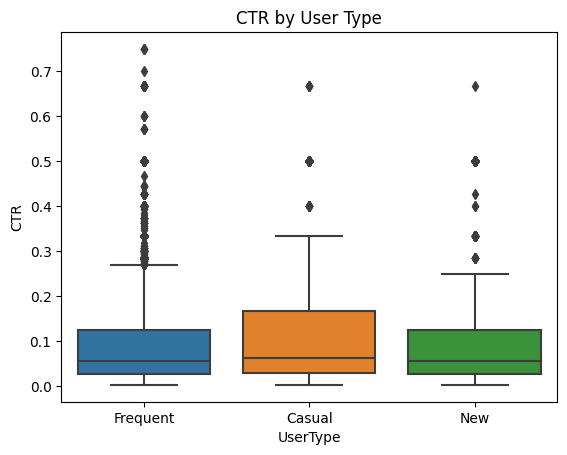

In [15]:
def user_type(length):
    if length == 0:
        return 'New'
    elif length < 5:
        return 'Casual'
    else:
        return 'Frequent'

behaviors['UserType'] = behaviors['HistoryLength'].apply(user_type)
sns.boxplot(data=behaviors, x='UserType', y='CTR')
plt.title("CTR by User Type")
plt.show()

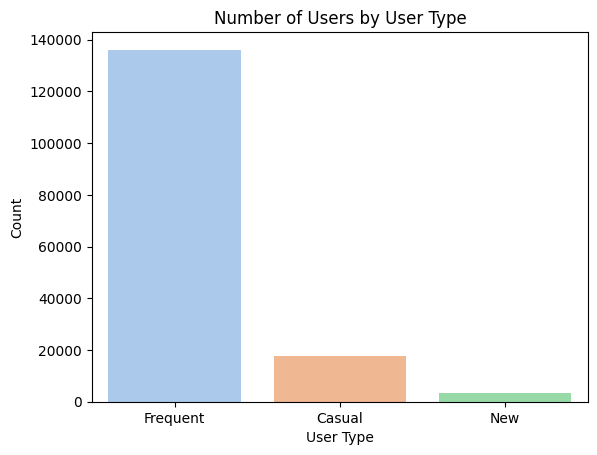

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count users in each segment
user_type_counts = behaviors['UserType'].value_counts().reset_index()
user_type_counts.columns = ['UserType', 'Count']

# Bar chart
sns.barplot(data=user_type_counts, x='UserType', y='Count', palette='pastel')
plt.title("Number of Users by User Type")
plt.xlabel("User Type")
plt.ylabel("Count")
plt.show()

7. Top Impressions per User
   
Average number of impressions per user

Distribution of impressions length

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


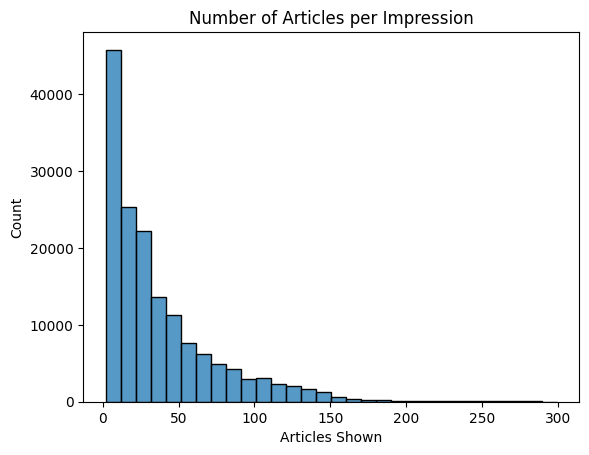

In [17]:
behaviors['ImpressionCount'] = behaviors['Impressions'].apply(lambda x: len(x.split()))
sns.histplot(behaviors['ImpressionCount'], bins=30)
plt.title("Number of Articles per Impression")
plt.xlabel("Articles Shown")
plt.show()

PART 2: EDA for news.tsv

1. Basic Info
Shape, null values

Unique news articles

In [18]:
print(news.shape)
print(news.isnull().sum())
print("Unique News IDs:", news['NewsID'].nunique())

(51282, 8)
NewsID                 0
Category               0
SubCategory            0
Title                  0
Abstract            2666
URL                    0
TitleEntities          3
AbstractEntities       4
dtype: int64
Unique News IDs: 51282


2. Category Distribution
   
Most common categories and subcategories

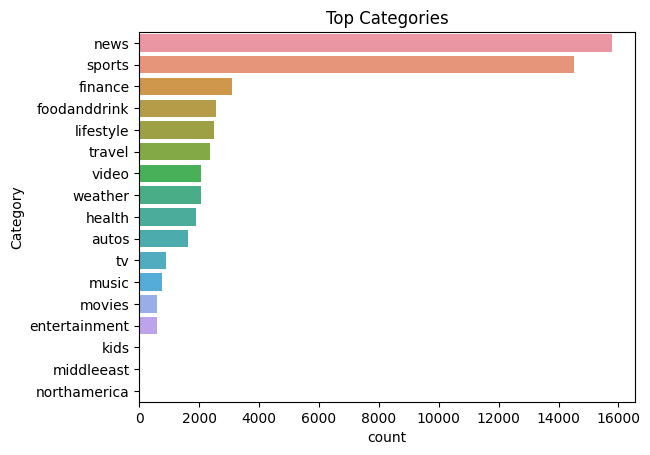

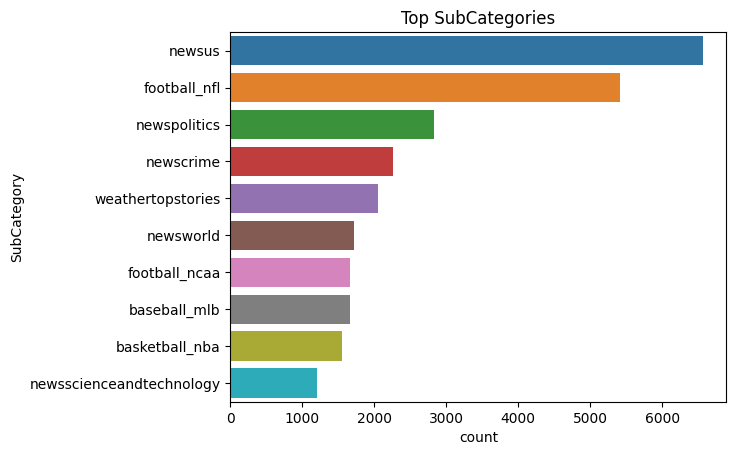

In [19]:
sns.countplot(data=news, y='Category', order=news['Category'].value_counts().index)
plt.title("Top Categories")
plt.show()

sns.countplot(data=news, y='SubCategory', order=news['SubCategory'].value_counts().index[:10])
plt.title("Top SubCategories")
plt.show()

3. Title and Abstract Lengths
   
Analyze word count in title and abstract

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


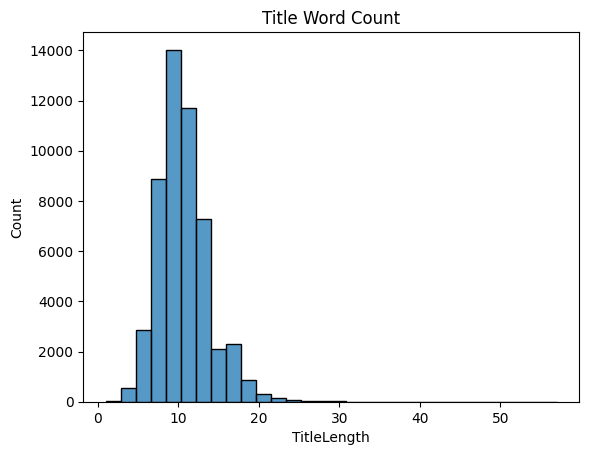

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


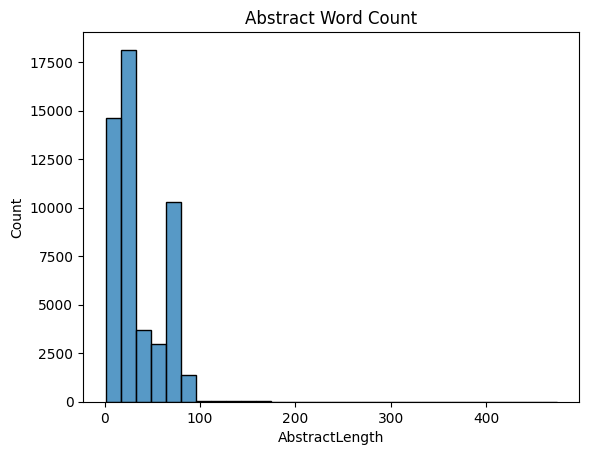

In [20]:
news['TitleLength'] = news['Title'].apply(lambda x: len(str(x).split()))
news['AbstractLength'] = news['Abstract'].apply(lambda x: len(str(x).split()))

# Plot
sns.histplot(news['TitleLength'], bins=30)
plt.title("Title Word Count")
plt.show()

sns.histplot(news['AbstractLength'], bins=30)
plt.title("Abstract Word Count")
plt.show()

4. Entity Analysis
   
Most frequently mentioned entities in titles and abstracts



In [21]:
news['TitleEntities'] = news['TitleEntities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
news['AbstractEntities'] = news['AbstractEntities'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

title_entity_labels = [ent['Label'] for row in news['TitleEntities'] for ent in row]
abstract_entity_labels = [ent['Label'] for row in news['AbstractEntities'] for ent in row]

# Frequency
title_entity_freq = pd.Series(title_entity_labels).value_counts().head(10)
abstract_entity_freq = pd.Series(abstract_entity_labels).value_counts().head(10)

print("Top Title Entities:\n", title_entity_freq)
print("Top Abstract Entities:\n", abstract_entity_freq)


Top Title Entities:
 Donald Trump                        1501
National Football League             510
United States                        398
New England Patriots                 392
Houston Astros                       369
California                           339
Republican Party (United States)     289
Democratic Party (United States)     273
Florida                              265
Ukraine                              263
Name: count, dtype: int64
Top Abstract Entities:
 Donald Trump                        1821
United States                       1102
National Football League             697
California                           584
New England Patriots                 547
Democratic Party (United States)     449
Republican Party (United States)     432
Houston Astros                       412
Ukraine                              388
Florida                              382
Name: count, dtype: int64


5. Duplicate News Titles
   
Check if there are duplicate news titles (potential republished content).

In [23]:
duplicate_titles = news['Title'].duplicated().sum()
print("Number of duplicate news titles:", duplicate_titles)

Number of duplicate news titles: 848


6. Category vs. Abstract/Title Length
   
Do certain categories tend to have longer or shorter abstracts/titles?

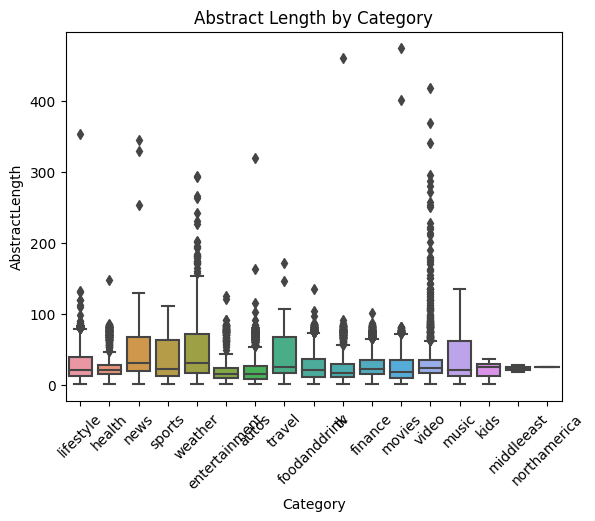

In [24]:
sns.boxplot(data=news, x='Category', y='AbstractLength')
plt.xticks(rotation=45)
plt.title("Abstract Length by Category")
plt.show()

8. TF-IDF Keyword Extraction
    
Identify top keywords in titles or abstracts using TF-IDF.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
X = vectorizer.fit_transform(news['Title'].fillna(''))
keywords = vectorizer.get_feature_names_out()

print("Top TF-IDF keywords in news titles:\n", keywords)

Top TF-IDF keywords in news titles:
 ['2019' 'best' 'day' 'football' 'game' 'home' 'impeachment' 'man' 'new'
 'old' 'police' 'report' 'says' 'school' 'state' 'trump' 'vs' 'week' 'win'
 'year']


9. Category-Entity Heatmap
   
Map how entities are distributed across different categories.

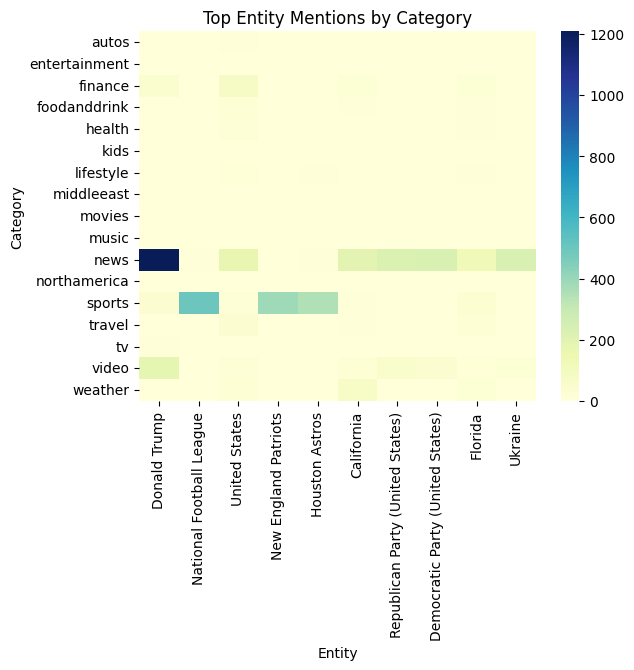

In [26]:
from collections import defaultdict

category_entity_map = defaultdict(list)

for _, row in news.iterrows():
    category = row['Category']
    for ent in row['TitleEntities']:
        category_entity_map[category].append(ent['Label'])

df = pd.DataFrame([
    (cat, ent) for cat, ents in category_entity_map.items()
    for ent in ents
])

heatmap_data = df.groupby([0, 1]).size().unstack(fill_value=0)
top_entities = heatmap_data.sum().sort_values(ascending=False).head(10).index
sns.heatmap(heatmap_data[top_entities], cmap='YlGnBu')
plt.title("Top Entity Mentions by Category")
plt.ylabel("Category")
plt.xlabel("Entity")
plt.show()
